In [2]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1000, noise=0.05)
from sklearn.mixture import GaussianMixture
gm  = GaussianMixture(n_components=3, n_init = 10) 
gm.fit(X)

,n_components,3
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,10
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,None


In [3]:
gm.weights_

array([0.60487015, 0.20059039, 0.19453946])

In [4]:
gm.means_

array([[ 0.51070258,  0.24272842],
       [-0.75332705,  0.55994927],
       [ 1.76867025, -0.03447655]])

In [5]:
gm.covariances_

array([[[ 0.17783504, -0.1116759 ],
        [-0.1116759 ,  0.29317134]],

       [[ 0.05308308,  0.06215387],
        [ 0.06215387,  0.08909736]],

       [[ 0.0448278 ,  0.05525248],
        [ 0.05525248,  0.08533947]]])

In [6]:
gm.converged_

True

In [7]:
gm.predict(X)

array([0, 0, 0, 2, 0, 0, 1, 1, 1, 1, 1, 2, 0, 0, 1, 2, 2, 0, 0, 0, 0, 0,
       2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 2, 0, 2,
       0, 2, 2, 1, 0, 0, 0, 0, 2, 0, 1, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 2, 0, 0, 0, 2, 2, 0, 1, 2, 2, 1, 2, 2, 0, 2, 0, 2, 1, 2, 1,
       0, 0, 1, 1, 0, 2, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 1, 2, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2,
       0, 0, 0, 0, 0, 1, 2, 2, 1, 0, 1, 1, 2, 0, 0, 0, 0, 1, 1, 2, 2, 0,
       0, 2, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 2, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 2, 2, 0, 1, 0, 0, 1, 2, 1, 0, 0, 0, 0, 2,
       0, 2, 2, 0, 1, 0, 1, 2, 1, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 2, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 2, 0, 2, 1, 0, 0, 2, 1, 2, 0, 1, 0, 2, 0,
       0, 0, 1, 0, 0, 0, 0, 2, 0, 1, 1, 0, 0, 1, 0, 2, 1, 0, 1, 2, 0, 0,
       2, 1, 0, 0, 0, 0, 2, 0, 0, 0, 0, 1, 0, 0, 1,

In [8]:
gm.predict_proba(X)

array([[1.00000000e+000, 5.99402432e-040, 6.62118994e-060],
       [1.00000000e+000, 3.60808743e-090, 1.94968627e-020],
       [1.00000000e+000, 5.96465662e-065, 2.77932661e-035],
       ...,
       [1.00000000e+000, 1.87309360e-029, 9.37331615e-077],
       [1.00000000e+000, 1.62436857e-062, 1.71459620e-037],
       [5.47036784e-002, 7.12630745e-191, 9.45296322e-001]],
      shape=(1000, 3))

A Gaussian mixture model is a generative model, meaning you can sample new
instances from it (note that they are ordered by cluster index

In [9]:
X_new, y_new = gm.sample(6)

In [10]:
X_new

array([[ 0.29533787,  0.49059819],
       [ 0.61297006,  0.68756455],
       [-0.2579991 ,  0.63910225],
       [ 0.07618537,  0.12515451],
       [ 0.75292019, -0.21127878],
       [ 0.48749029, -0.31619467]])

In [11]:
y_new

array([0, 0, 0, 0, 0, 0])

### Anomaly detection using GMM

In [12]:
import numpy as np
densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 4)
anomalies = X[densities < density_threshold]

In [13]:
anomalies

array([[-0.94213772,  0.0727244 ],
       [ 1.27024866, -0.42268446],
       [ 1.29385547, -0.37725168],
       [ 1.2248298 , -0.48894091],
       [-1.01117245, -0.00445352],
       [-0.97975266, -0.01292725],
       [ 1.15076533, -0.56254248],
       [ 1.23483839, -0.37753205],
       [-0.97315807,  0.04887906],
       [ 1.1873822 , -0.53944157],
       [-0.09089852,  1.09133832],
       [ 1.86968446,  0.42704153],
       [ 1.2155444 , -0.4994936 ],
       [ 1.24475775, -0.46722614],
       [ 1.23816021, -0.41655761],
       [ 1.96836683,  0.51491386],
       [-0.98696884,  0.02365194],
       [ 1.24345431, -0.43733453],
       [-0.94747633, -0.04543568],
       [ 1.2844216 , -0.43366953],
       [ 1.2168042 , -0.48719702],
       [ 1.97187052,  0.47603919],
       [ 1.30581378, -0.36482421],
       [ 1.98194803,  0.50483894],
       [-1.02584822,  0.01118337],
       [ 1.73311617, -0.37919722],
       [ 1.2277403 , -0.52207982],
       [ 2.05330904,  0.56390053],
       [-0.9676907 ,

### AIC and BIC to select the appopriate number of clusters 

select the best value of k for which the AIC and BIC is lowest


In [14]:
print(gm.aic(X))
print(gm.bic(X))

2711.114047939681
2794.5458876823773


Finding the value of k

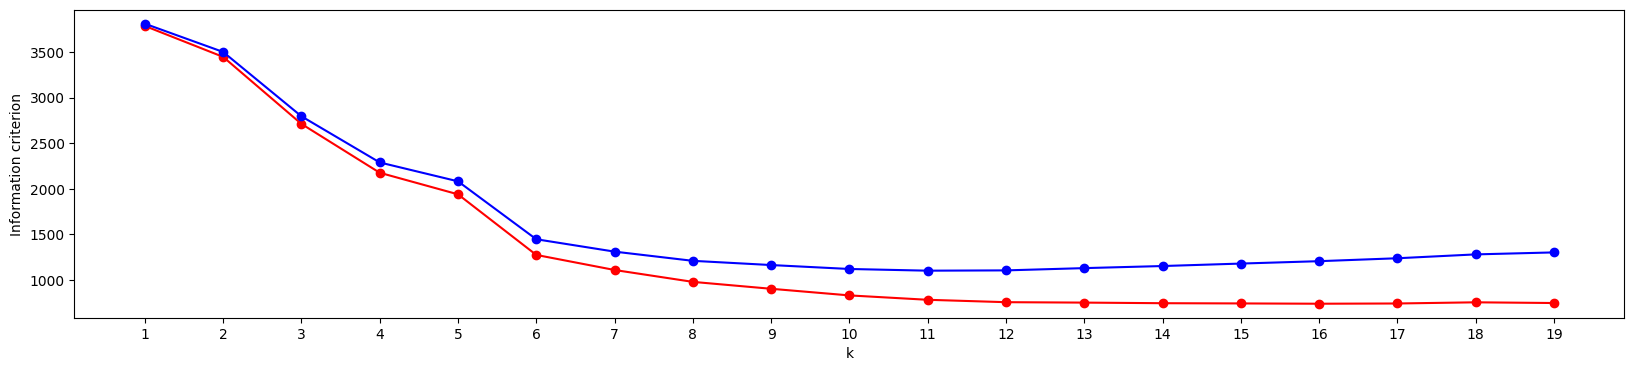

In [28]:
import matplotlib.pyplot as plt
k = np.arange(1, 20)
aic = []
bic = []
for i in range(1, 20):
    gm = GaussianMixture(n_components=i, n_init = 10)
    gm.fit(X)
    aic.append(gm.aic(X))
    bic.append(gm.bic(X))

plt.figure(figsize=(20, 4))
plt.plot(k, aic, "bo",marker='o', linestyle='-', color='r')
plt.plot(k, bic, "ro",marker='o', linestyle='-', color='b')
plt.xlabel("k")
plt.ylabel("Information criterion")
plt.xticks(k)
plt.show()
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)